# House Price Prediction using Machine Learning

This project aims to predict house prices using machine learning techniques based on various property characteristics such as living area, number of bedrooms, bathrooms, lot size, and year built. The project follows a complete machine learning workflow, including data exploration, cleaning, model training, evaluation, and comparison.

## Import Libraries

The required Python Libraries were imported for data manipulation, visualization, model development, and evaluation.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

## Load Dataset

The dataset was loaded into a pandas DataFrame for analysis. Eqach row represents a house, while each column contains information about the property's characteristics and selling price.

In [180]:
df = pd.read_csv("../data/data.csv")

### Initial Data Exploration

Before building any mode, the dataset was explored to understand its structure, identify the available features, and check for any obvious issues such as missing values or incorrect data types.

In [181]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,"313,000.00",3.00,1.50,1340,7912,1.50,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,"2,384,000.00",5.00,2.50,3650,9050,2.00,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,"342,000.00",3.00,2.00,1930,11947,1.00,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,"420,000.00",3.00,2.25,2000,8030,1.00,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,"550,000.00",4.00,2.50,1940,10500,1.00,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [182]:
df.shape

(4600, 18)

In [183]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')

In [184]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

In [185]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,"4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00"
mean,"551,962.99",3.40,2.16,"2,139.35","14,852.52",1.51,0.01,0.24,3.45,"1,827.27",312.08,"1,970.79",808.61
std,"563,834.70",0.91,0.78,963.21,"35,884.44",0.54,0.08,0.78,0.68,862.17,464.14,29.73,979.41
min,0.00,0.00,0.00,370.00,638.00,1.00,0.00,0.00,1.00,370.00,0.00,"1,900.00",0.00
25%,"322,875.00",3.00,1.75,"1,460.00","5,000.75",1.00,0.00,0.00,3.00,"1,190.00",0.00,"1,951.00",0.00
50%,"460,943.46",3.00,2.25,"1,980.00","7,683.00",1.50,0.00,0.00,3.00,"1,590.00",0.00,"1,976.00",0.00
75%,"654,962.50",4.00,2.50,"2,620.00","11,001.25",2.00,0.00,0.00,4.00,"2,300.00",610.00,"1,997.00","1,999.00"
max,"26,590,000.00",9.00,8.00,"13,540.00","1,074,218.00",3.50,1.00,4.00,5.00,"9,410.00","4,820.00","2,014.00","2,014.00"


In [186]:
pd.set_option("display.float_format", "{:,.2f}".format)

In [187]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,"4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00"
mean,"551,962.99",3.40,2.16,"2,139.35","14,852.52",1.51,0.01,0.24,3.45,"1,827.27",312.08,"1,970.79",808.61
std,"563,834.70",0.91,0.78,963.21,"35,884.44",0.54,0.08,0.78,0.68,862.17,464.14,29.73,979.41
min,0.00,0.00,0.00,370.00,638.00,1.00,0.00,0.00,1.00,370.00,0.00,"1,900.00",0.00
25%,"322,875.00",3.00,1.75,"1,460.00","5,000.75",1.00,0.00,0.00,3.00,"1,190.00",0.00,"1,951.00",0.00
50%,"460,943.46",3.00,2.25,"1,980.00","7,683.00",1.50,0.00,0.00,3.00,"1,590.00",0.00,"1,976.00",0.00
75%,"654,962.50",4.00,2.50,"2,620.00","11,001.25",2.00,0.00,0.00,4.00,"2,300.00",610.00,"1,997.00","1,999.00"
max,"26,590,000.00",9.00,8.00,"13,540.00","1,074,218.00",3.50,1.00,4.00,5.00,"9,410.00","4,820.00","2,014.00","2,014.00"


<function matplotlib.pyplot.show(close=None, block=None)>

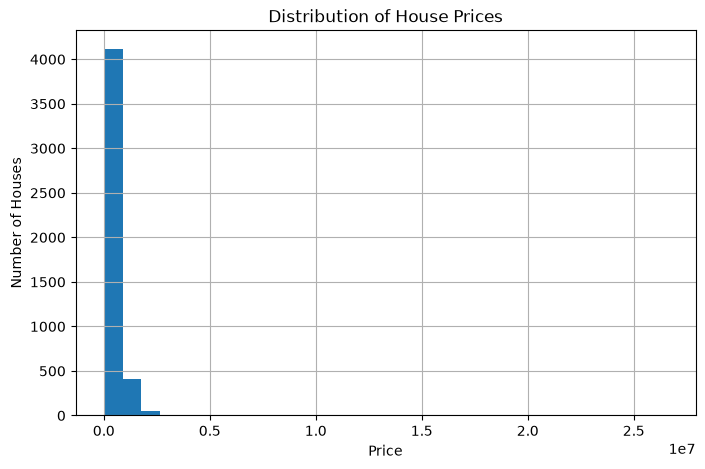

In [188]:
df["price"].hist(bins=30, figsize=(8,5))
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.show

In [189]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [190]:
df.duplicated().sum()

np.int64(0)

In [191]:
df[df["price"] == 0]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
4354,2014-05-05 00:00:00,0.00,3.00,1.75,1490,10125,1.00,0,0,4,1490,0,1962,0,3911 S 328th St,Federal Way,WA 98001,USA
4356,2014-05-05 00:00:00,0.00,4.00,2.75,2600,5390,1.00,0,0,4,1300,1300,1960,2001,2120 31st Ave W,Seattle,WA 98199,USA
4357,2014-05-05 00:00:00,0.00,6.00,2.75,3200,9200,1.00,0,2,4,1600,1600,1953,1983,12271 Marine View Dr SW,Burien,WA 98146,USA
4358,2014-05-06 00:00:00,0.00,5.00,3.50,3480,36615,2.00,0,0,4,2490,990,1983,0,21809 SE 38th Pl,Issaquah,WA 98075,USA
4361,2014-05-07 00:00:00,0.00,5.00,1.50,1500,7112,1.00,0,0,5,760,740,1920,0,14901-14999 12th Ave SW,Burien,WA 98166,USA
4362,2014-05-07 00:00:00,0.00,4.00,4.00,3680,18804,2.00,0,0,3,3680,0,1990,2009,1223-1237 244th Ave NE,Sammamish,WA 98074,USA
4374,2014-05-09 00:00:00,0.00,2.00,2.50,2200,188200,1.00,0,3,3,2200,0,2007,0,39612 254th Ave SE,Enumclaw,WA 98022,USA
4376,2014-05-09 00:00:00,0.00,4.00,2.25,2170,10500,1.00,0,2,4,1270,900,1960,2001,216 SW 183rd St,Normandy Park,WA 98166,USA
4382,2014-05-12 00:00:00,0.00,5.00,4.50,4630,6324,2.00,0,0,3,3210,1420,2006,0,6925 Oakmont Ave SE,Snoqualmie,WA 98065,USA
4383,2014-05-13 00:00:00,0.00,5.00,4.00,4430,9000,2.00,0,0,3,4430,0,2013,1923,9235 NE 5th St,Bellevue,WA 98004,USA


In [192]:
df[df["bedrooms"] == 00]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
2365,2014-06-12 00:00:00,"1,095,000.00",0.00,0.00,3064,4764,3.50,0,2,3,3064,0,1990,2009,814 E Howe St,Seattle,WA 98102,USA
3209,2014-06-24 00:00:00,"1,295,648.00",0.00,0.00,4810,28008,2.00,0,0,3,4810,0,1990,2009,20418 NE 64th Pl,Redmond,WA 98053,USA


In [193]:
df[df["bathrooms"] == 00]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
2365,2014-06-12 00:00:00,"1,095,000.00",0.00,0.00,3064,4764,3.50,0,2,3,3064,0,1990,2009,814 E Howe St,Seattle,WA 98102,USA
3209,2014-06-24 00:00:00,"1,295,648.00",0.00,0.00,4810,28008,2.00,0,0,3,4810,0,1990,2009,20418 NE 64th Pl,Redmond,WA 98053,USA


In [194]:
df[["price","bedrooms","bathrooms"]].describe()


,price,bedrooms,bathrooms
count,"4,600.00","4,600.00","4,600.00"
mean,"551,962.99",3.40,2.16
std,"563,834.70",0.91,0.78
min,0.00,0.00,0.00
25%,"322,875.00",3.00,1.75
50%,"460,943.46",3.00,2.25
75%,"654,962.50",4.00,2.50
max,"26,590,000.00",9.00,8.00


In [195]:
df["bedrooms"].value_counts().sort_index()

bedrooms
0.00       2
1.00      38
2.00     566
3.00    2032
4.00    1531
5.00     353
6.00      61
7.00      14
8.00       2
9.00       1
Name: count, dtype: int64

In [196]:
df["bathrooms"].value_counts().sort_index()

bathrooms
0.00       2
0.75      17
1.00     743
1.25       3
1.50     291
1.75     629
2.00     427
2.25     419
2.50    1189
2.75     276
3.00     167
3.25     136
3.50     162
3.75      37
4.00      23
4.25      23
4.50      29
4.75       7
5.00       6
5.25       4
5.50       4
5.75       1
6.25       2
6.50       1
6.75       1
8.00       1
Name: count, dtype: int64

## Data Cleaning

The dataset was checked for missing values, duplicate records, and invalid entries. During model evaluation, several properties with a selling price of zero were identified. Since these records do not represent valid market transactions, they were removed from the dataset before retraining the models.

Properties with zero bedrooms or zero bathrooms were also removed to improved data quality.

In [197]:
df = df[(df["bedrooms"] > 0)  & (df["bathrooms"] > 0) & (df["price"] > 0)] 

In [198]:
df.shape

(4549, 18)

## Exploratory Data Analysis

Exploratory Data Analysis was performed to better understand the relationships between house features and selling price.

Visualizations such as histograms, scatter plots, boxplots, and a correlation heatmap were used to identify trends, outliers, and potential predictors.

In [199]:
correlation = df.corr(numeric_only=True)
correlation["price"].sort_values(ascending=False)

price            1.00
sqft_living      0.45
sqft_above       0.38
bathrooms        0.34
view             0.24
sqft_basement    0.22
bedrooms         0.21
floors           0.15
waterfront       0.15
sqft_lot         0.05
condition        0.04
yr_built         0.02
yr_renovated    -0.03
Name: price, dtype: float64

In [200]:
!pip install seaborn


[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [201]:
import seaborn as sns

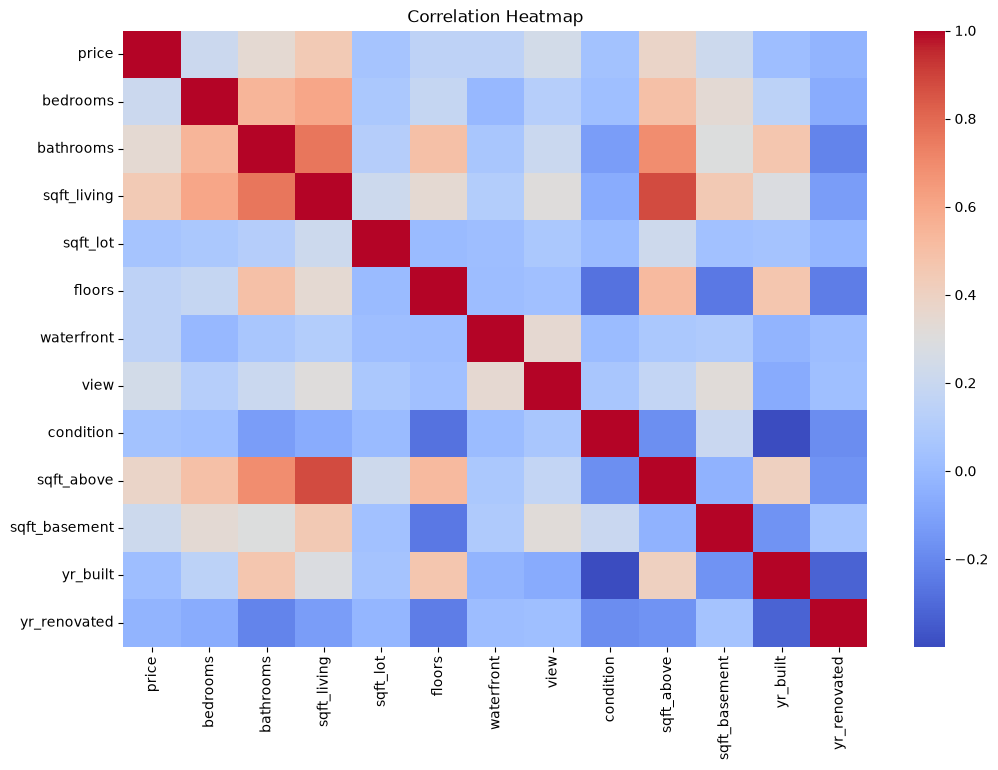

In [202]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

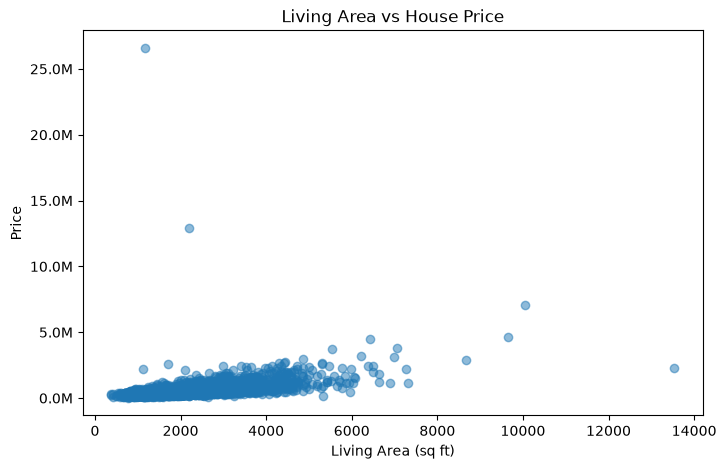

In [203]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(8,5))

plt.scatter(
    df["sqft_living"],
    df["price"],
    alpha=0.5
)

plt.title("Living Area vs House Price")
plt.xlabel("Living Area (sq ft)")
plt.ylabel("Price")

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))

plt.show()

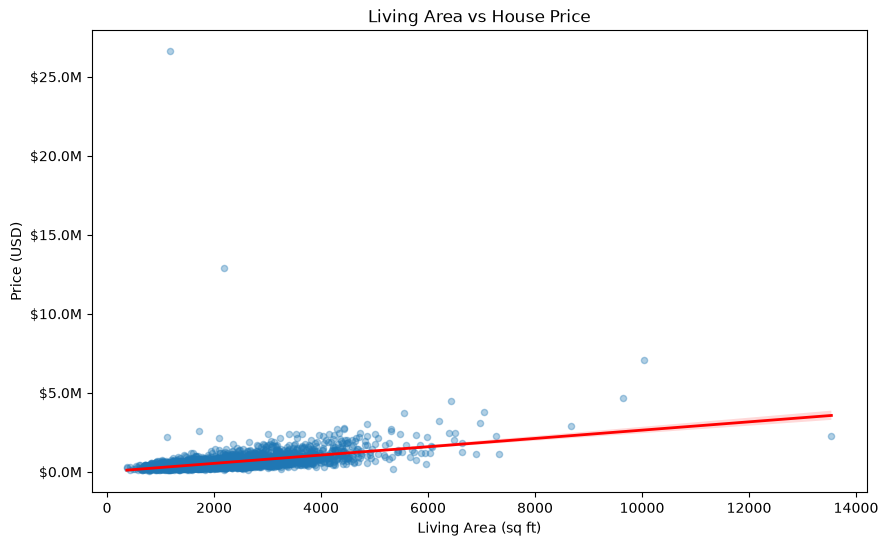

In [204]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="sqft_living",
    y="price",
    scatter_kws={"alpha": 0.35, "s": 20},
    line_kws={"color" : "red", "linewidth": 2}
)

plt.title("Living Area vs House Price")
plt.xlabel("Living Area (sq ft)")
plt.ylabel("Price (USD)")

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M'))

plt.show()

In [205]:
correlation["price"].sort_values(ascending=False)

price            1.00
sqft_living      0.45
sqft_above       0.38
bathrooms        0.34
view             0.24
sqft_basement    0.22
bedrooms         0.21
floors           0.15
waterfront       0.15
sqft_lot         0.05
condition        0.04
yr_built         0.02
yr_renovated    -0.03
Name: price, dtype: float64

In [206]:
df.nlargest(10, "price")[["price", "sqft_living", "bedrooms", "bathrooms", "view", "waterfront"]]

,price,sqft_living,bedrooms,bathrooms,view,waterfront
4350,"26,590,000.00",1180,3.00,2.00,0,0
4346,"12,899,000.00",2190,3.00,2.50,0,0
2286,"7,062,500.00",10040,5.00,4.50,2,1
2654,"4,668,000.00",9640,5.00,6.75,4,1
2761,"4,489,000.00",6430,4.00,3.00,0,0
3729,"3,800,000.00",7050,5.00,5.50,2,0
1637,"3,710,000.00",5550,4.00,3.50,2,0
252,"3,200,000.00",6210,7.00,4.50,2,0
1567,"3,100,000.00",6980,6.00,4.25,4,0
2772,"3,000,000.00",4850,4.00,4.25,4,1


C:\Users\geeca\AppData\Local\Temp\ipykernel_19020\4182411680.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["price"], vert=False)


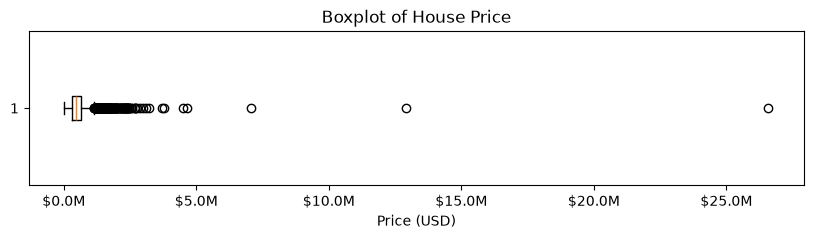

In [207]:
plt.figure(figsize=(10,2))

plt.boxplot(df["price"], vert=False)

plt.title("Boxplot of House Price")
plt.xlabel("Price (USD)")

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M'))

plt.show()

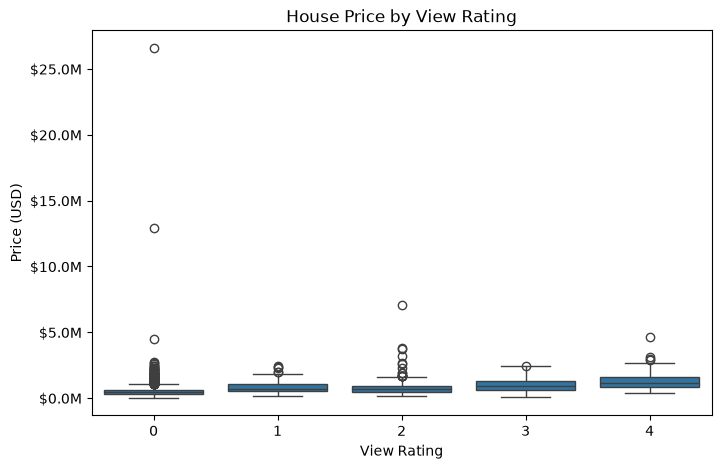

In [208]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="view",
    y="price"
)

plt.title("House Price by View Rating")
plt.xlabel("View Rating")
plt.ylabel("Price (USD)")

plt.gca().yaxis.set_major_formatter( FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M'))

plt.show()

## Feature Selection

Only numerical features related to the physical characteristics of each property were selected for model training. The target variable for prediction was the house selling price.

In [209]:
features = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "sqft_above",
    "sqft_basement",
    "yr_built",
    "yr_renovated"
]

X = df[features]
y = df["price"]

In [210]:
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,3.00,1.50,1340,7912,1.50,0,0,3,1340,0,1955,2005
1,5.00,2.50,3650,9050,2.00,0,4,5,3370,280,1921,0
2,3.00,2.00,1930,11947,1.00,0,0,4,1930,0,1966,0
3,3.00,2.25,2000,8030,1.00,0,0,4,1000,1000,1963,0
4,4.00,2.50,1940,10500,1.00,0,0,4,1140,800,1976,1992


## Train-Test Split

The dataset was divided into training and testing sets. The training set was used to build the models, while the testing set was reserved for evaluating how well the models perform on unseen data.

In [211]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [212]:
print(X_train.shape)
print(X_test.shape)

(3639, 12)
(910, 12)


## Model 1: Linear Regression

Linear Regression was used as the baseline model. This algorithm estimates house prices by learning a linear relationship between the selected features and the target variable.

In [213]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[-60438.77, 71694.5 , 165.4 ,..., 63.13, -2516.03, 5.72]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['bedrooms','bathrooms','sqft_living',...,'sqft_basement','yr_built', 'yr_renovated']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.84e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(11)


In [214]:
predictions = model.predict(X_test)

In [215]:
results = X_test.copy()
results["Actual Price"] = y_test.values
results["Predicted Price"] = predictions

results[["Actual Price", "Predicted Price"]].head(10)

,Actual Price,Predicted Price
471,"1,225,000.00","1,343,073.77"
2518,"496,752.00","607,265.95"
23,"612,500.00","650,612.73"
3921,"529,950.00","478,361.10"
135,"615,000.00","507,297.39"
1789,"432,000.00","515,774.22"
3335,"305,000.00","251,623.88"
3624,"265,000.00","479,499.67"
2320,"349,000.00","372,347.71"
3260,"839,000.00","664,907.70"


## Model Evaluation

The performance of the Linear Regression model was evaluated using the Mean Absolute Error (MAE), Mean Squared  (MSE) and the coefficient of determination (R²)

Initial evaluation highlighted unusually large prediction errors, leading to further investigation of the dataset. After removing invalid records with a selling price of zero, the model was retrained, resulting in noticeably improved performance

In [216]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)

print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²: ${r2:.3f}")

MAE: $166,236.18
RMSE: $250,418.64
R²: $0.595


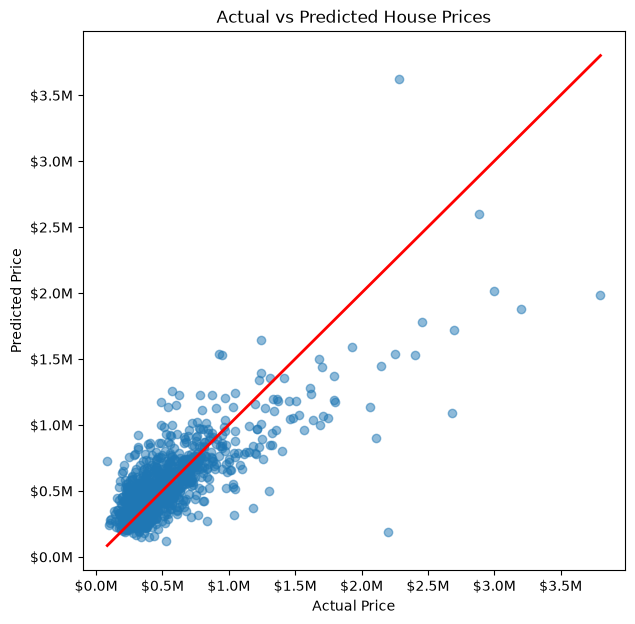

In [217]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, predictions, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M')
)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M')
)

plt.show()

In [218]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

results["Error"] = abs(results["Actual"] - results["Predicted"])

results.sort_values("Error", ascending=False).head(10)

,Actual,Predicted,Error
4348,"2,199,900.00","189,183.77","2,010,716.23"
3729,"3,800,000.00","1,983,718.38","1,816,281.62"
4261,"2,680,000.00","1,086,794.08","1,593,205.92"
122,"2,280,000.00","3,622,018.12","1,342,018.12"
252,"3,200,000.00","1,875,369.83","1,324,630.17"
2978,"2,110,000.00","901,987.21","1,208,012.79"
2772,"3,000,000.00","2,011,851.05","988,148.95"
2083,"2,700,000.00","1,720,738.16","979,261.84"
3699,"2,065,000.00","1,132,201.07","932,798.93"
2980,"2,400,000.00","1,533,063.25","866,936.75"


## Model 2: Random Forest

A Random Forest Regressor was trained using the same training and testing data to compare its performance against the baseline Linear Regression model

A tuned version of the random forest model was also evaluated by adjusting selected hyperparameters

In [219]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [220]:
rf_predictions = rf_model.predict(X_test)

In [221]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, rf_predictions)
rmse = mean_squared_error(y_test, rf_predictions) ** 0.5
r2 = r2_score(y_test, rf_predictions)

print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²: ${r2:.3f}")

MAE: $174,217.04
RMSE: $289,938.95
R²: $0.457


In [222]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": rf_predictions
})

comparison.head(10)

,Actual Price,Predicted Price
471,"1,225,000.00","1,194,702.06"
2518,"496,752.00","565,243.46"
23,"612,500.00","721,845.38"
3921,"529,950.00","358,491.53"
135,"615,000.00","582,073.65"
1789,"432,000.00","395,178.69"
3335,"305,000.00","379,928.38"
3624,"265,000.00","430,078.65"
2320,"349,000.00","453,290.24"
3260,"839,000.00","763,904.11"


In [223]:
comparison["Error"] = abs(
    comparison["Actual Price"] -
    comparison["Predicted Price"]
)

comparison.sort_values(
    "Error",
    ascending=False
).head(10)

,Actual Price,Predicted Price,Error
122,"2,280,000.00","4,796,534.28","2,516,534.28"
4348,"2,199,900.00","286,497.72","1,913,402.28"
4261,"2,680,000.00","901,954.50","1,778,045.50"
252,"3,200,000.00","1,483,382.50","1,716,617.50"
3004,"1,240,000.00","2,788,085.90","1,548,085.90"
2772,"3,000,000.00","1,480,244.70","1,519,755.30"
132,"210,000.00","1,706,706.61","1,496,706.61"
2083,"2,700,000.00","1,298,178.09","1,401,821.91"
2687,"250,000.00","1,616,208.25","1,366,208.25"
4307,"657,500.00","1,834,997.11","1,177,497.11"


In [224]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
2,sqft_living,0.35
10,yr_built,0.16
3,sqft_lot,0.13
8,sqft_above,0.09
7,condition,0.07
1,bathrooms,0.07
9,sqft_basement,0.04
0,bedrooms,0.03
4,floors,0.03
6,view,0.02


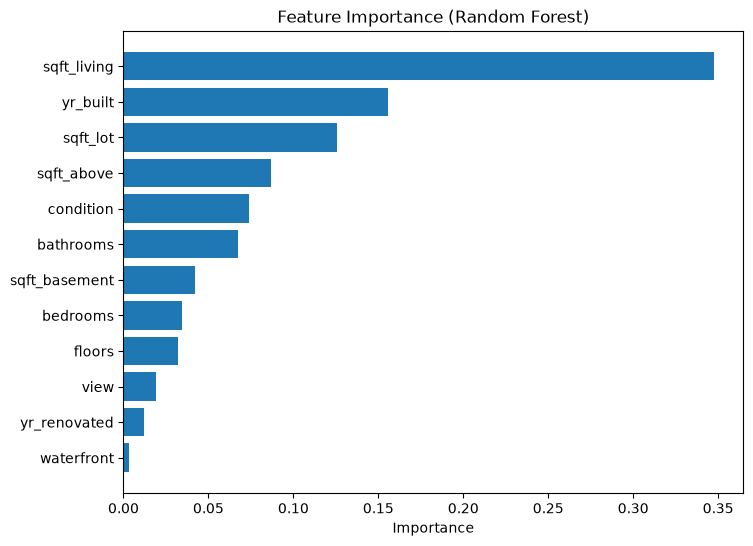

In [225]:
plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

In [226]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42
)

In [227]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [228]:
rf_predictions = rf_model.predict(X_test)

In [229]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, rf_predictions)
rmse = mean_squared_error(y_test, rf_predictions) ** 0.5
r2 = r2_score(y_test, rf_predictions)

print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²: ${r2:.3f}")

MAE: $171,590.88
RMSE: $276,982.91
R²: $0.504


In [230]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": rf_predictions
})

comparison.head(10)


,Actual Price,Predicted Price
471,"1,225,000.00","1,219,637.33"
2518,"496,752.00","551,466.94"
23,"612,500.00","687,478.34"
3921,"529,950.00","381,497.26"
135,"615,000.00","582,118.62"
1789,"432,000.00","424,869.41"
3335,"305,000.00","369,181.53"
3624,"265,000.00","431,751.51"
2320,"349,000.00","449,039.42"
3260,"839,000.00","709,081.23"


In [231]:
comparison["Error"] = abs(
    comparison["Actual Price"] -
    comparison["Predicted Price"]
)

comparison.sort_values(
    "Error",
    ascending=False
).head(10)

,Actual Price,Predicted Price,Error
4348,"2,199,900.00","285,556.16","1,914,343.84"
4261,"2,680,000.00","975,316.58","1,704,683.42"
2834,"659,500.00","2,358,327.66","1,698,827.66"
122,"2,280,000.00","3,860,349.22","1,580,349.22"
2772,"3,000,000.00","1,473,947.47","1,526,052.53"
3004,"1,240,000.00","2,691,111.93","1,451,111.93"
252,"3,200,000.00","1,815,970.45","1,384,029.55"
3729,"3,800,000.00","2,445,992.56","1,354,007.44"
2083,"2,700,000.00","1,389,910.21","1,310,089.79"
4307,"657,500.00","1,749,392.49","1,091,892.49"


In [232]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
2,sqft_living,0.42
10,yr_built,0.17
3,sqft_lot,0.11
8,sqft_above,0.10
1,bathrooms,0.06
9,sqft_basement,0.04
7,condition,0.03
0,bedrooms,0.02
6,view,0.02
11,yr_renovated,0.02


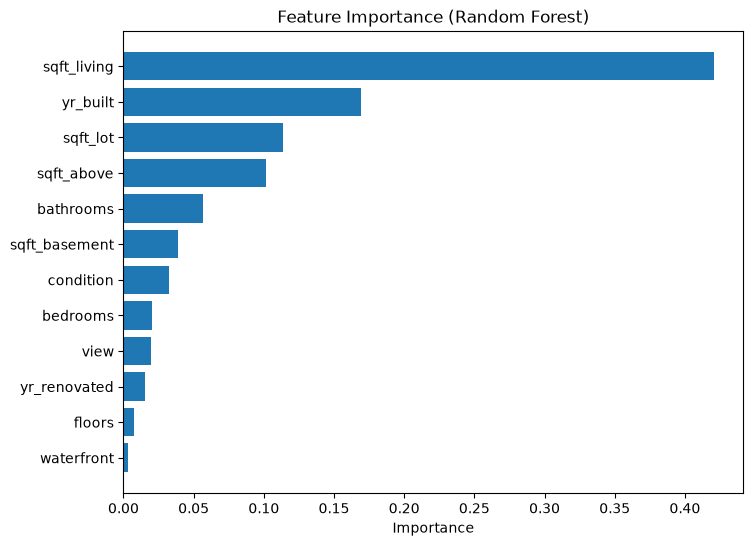

In [233]:
plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

## Conclusion

This project demonstrated the complete workflow of a machine learning regression task, from data exploration and clearning to model training and evaluation.

One of the most important findings was that the data quality had a significant impact on the model performance. Removing invalid records improved the results of the baseline model.

Among the models tested, Linear Regression achieved the best overall performance using the selected numerical features. Future improvements could include incorporating location-based features and exploring additional feature engineering techniques to further improve prediction accuracy.

In [234]:
df.to_csv("cleaned_house_prices.csv", index=False)

In [235]:
comparison_metrics = pd.DataFrame({
    "Model": [
        "LinearRegression",
        "Random Forest (Default)",
        "Random Forest (Tuned)"
    ],
    "MAE": [
        166236.18,
        174217.04,
        171590.88
    ],
    "RMSE": [
        250418.64,
        289938.95,
        276982.91
    ],
    "R2 Score": [
        0.595,
        0.457,
        0.504
    ]
})

comparison_metrics

,Model,MAE,RMSE,R2 Score
0,LinearRegression,"166,236.18","250,418.64",0.59
1,Random Forest (Default),"174,217.04","289,938.95",0.46
2,Random Forest (Tuned),"171,590.88","276,982.91",0.50


In [236]:
comparison_metrics.to_csv("model_metrics.csv", index=False)

In [237]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance.to_csv("feature_importance.csv", index=False)

In [238]:
df["price"].quantile([0.25, 0.50, 0.75])

0.25   326,100.00
0.50   465,000.00
0.75   657,500.00
Name: price, dtype: float64

In [239]:
def price_category(price):
    if price <= 326100:
        return "Lower 25%"
    elif price <= 465000:
        return "25% - 50%"
    elif price <= 657500:
        return "50% - 75%"
    else:
        return "Top 25%"

df["price_category"] = df["price"].apply(price_category)

In [240]:
df.to_csv("cleaned_house_prices.csv", index=False)

In [241]:
results.to_csv(
    "../data/predictions.csv",
    index=False
)